# Лабораторная работа № 7
Ручная реалиация нейронной сети

Данные про недвижимость из 1 лабораторной работы уже очищенные и преобразованные.

Задачи:
- Реализовать архитектуру полносвязной нейронной сети для задачи регрессии
- Протестировать различные архитектуры

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
!gdown 1XgP7PzMdDxMm7nVvTL6pjAoa6aC_lHa5
data = pd.read_csv("lab1_clear.csv")
data.info()

Downloading...
From: https://drive.google.com/uc?id=1XgP7PzMdDxMm7nVvTL6pjAoa6aC_lHa5
To: /content/lab1_clear.csv
100% 2.27M/2.27M [00:00<00:00, 155MB/s]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18696 entries, 0 to 18695
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       18696 non-null  int64  
 1   price            18696 non-null  float64
 2   total_area       18696 non-null  float64
 3   rooms            18696 non-null  int64  
 4   ceiling_height   18696 non-null  float64
 5   floors_total     18696 non-null  int64  
 6   living_area      18696 non-null  float64
 7   floor            18696 non-null  int64  
 8   studio           18696 non-null  bool   
 9   kitchen_area     18696 non-null  float64
 10  floor_coef       18696 non-null  float64
 11  is_balcony       18696 non-null  bool   
 12  is_first_floor   18696 non-null  bool   
 13  is_last_floor    18696 non-null  bool   
 

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
train_num_columns = data.select_dtypes([np.number]).drop("price", axis=1).columns
X, y = data.drop("price", axis=1), data.price

In [ ]:
scaler = StandardScaler()
X[train_num_columns] = scaler.fit_transform(X[train_num_columns].values)
X.shape

(18696, 21)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Использую RELU так как решаю задачу регрессии

In [ ]:
def RELU(x):
    x = np.asarray(x, dtype=np.float64)
    return np.maximum(0, x)

def LeakyRELU(x, a=0.01):
    x = np.asarray(x, dtype=np.float64)
    return np.where(x > 0, x, a * x)

In [ ]:
class FullConnectedLayer:
  def __init__(self, input_dim, out, func_act=None):
      self.weights = np.random.randn(input_dim, out).astype(np.float64)
      self.bias = np.zeros((1, out), dtype=np.float64)
      self.func_act = func_act

      self.dW = np.zeros_like(self.weights)
      self.db = np.zeros_like(self.bias)

      self.mW = np.zeros_like(self.weights)
      self.vW = np.zeros_like(self.weights)
      self.mb = np.zeros_like(self.bias)
      self.vb = np.zeros_like(self.bias)

      self.t = 0

  def forward(self, x):
      x = np.asarray(x, dtype=np.float64)
      if x.ndim == 1:
          x = x.reshape(1, -1)
      self.x = x
      self.z = x @ self.weights + self.bias
      return self.func_act(self.z) if self.func_act else self.z

  def backward(self, grad):
      grad = np.asarray(grad, dtype=np.float64)

      if grad.ndim == 1:
          grad = grad.reshape(-1, 1)

      self.dW = self.x.T @ grad
      self.db = grad.sum(axis=0, keepdims=True)
      return grad

## Про функцию потерь

На лекции по математическим основам показали, что MSE выводиться исходя из максимизации правдоподобия, при нормально распределении ошибок. Я предполагаю, что ошибки распределены нормально и поэтому использую MSE

In [ ]:
def MSE(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def MSEgrad(y_pred, y_true):
    return 2 * (y_pred - y_true) / y_pred.shape[0]


def adam_step(model, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
    for layer in model.layers:
      layer.t += 1

      dW, db = layer.dW, layer.db

      layer.mW = beta1 * layer.mW + (1 - beta1) * dW
      layer.vW = beta2 * layer.vW + (1 - beta2) * (dW ** 2)

      mW_hat = layer.mW / (1 - beta1 ** layer.t)
      vW_hat = layer.vW / (1 - beta2 ** layer.t)

      layer.weights -= lr * mW_hat / (np.sqrt(vW_hat) + eps)

      layer.mb = beta1 * layer.mb + (1 - beta1) * db
      layer.vb = beta2 * layer.vb + (1 - beta2) * (db ** 2)

      mb_hat = layer.mb / (1 - beta1 ** layer.t)
      vb_hat = layer.vb / (1 - beta2 ** layer.t)

      layer.bias -= lr * mb_hat / (np.sqrt(vb_hat) + eps)

In [ ]:
def train(model, X, y, epochs=10, batch_size=512, lr=0.001):
    X = np.asarray(X, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    n = X.shape[0]
    losses = []

    for epoch in range(epochs):
      for i in range(0, n, batch_size):
          xb = X[i:i+batch_size]
          yb = y[i:i+batch_size]

          pred = model.forward(xb)
          loss = MSE(pred, yb)
          grad = MSEgrad(pred, yb)

          model.backward(grad)
          adam_step(model, lr=lr)

          losses.append(loss)

      if epoch % 10 == 0:
        print(f"Epoch {epoch+1}, loss = {np.mean(losses):.6f}")

In [ ]:
class NN:
  def __init__(self, *layers) -> None:
      self.layers = layers

  def forward(self, x):
    for layer in self.layers:
        x = layer.forward(x)
    return x

  def backward(self, grad):
    for layer in reversed(self.layers):
        grad = layer.backward(grad)
    return grad

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Архитектура 1

In [ ]:
model = NN(
    FullConnectedLayer(X.shape[1], 128, RELU),
    FullConnectedLayer(128, 32, RELU),
    FullConnectedLayer(32, 1),
)

train(model, X_train.values, y_train.values.reshape(-1, 1), epochs=200, lr=0.3)

Epoch 1, loss = 13689365926922.556641
Epoch 11, loss = 2780165564298.629395
Epoch 21, loss = 2157171435486.478271
Epoch 31, loss = 1934664582903.173096
Epoch 41, loss = 1821834949774.141846
Epoch 51, loss = 1755032278063.137939
Epoch 61, loss = 1711253847868.229980
Epoch 71, loss = 1679413364986.677734
Epoch 81, loss = 1654614434850.144043
Epoch 91, loss = 1635136751114.040527
Epoch 101, loss = 1619848796377.819092
Epoch 111, loss = 1607740144532.766846
Epoch 121, loss = 1597970490885.929199
Epoch 131, loss = 1589944420165.864014
Epoch 141, loss = 1583263608660.933594
Epoch 151, loss = 1577649975918.812256
Epoch 161, loss = 1572897921940.426514
Epoch 171, loss = 1568847762660.813965
Epoch 181, loss = 1565368947948.522949
Epoch 191, loss = 1562346832795.648926


In [ ]:
y_pred = model.forward(X_test)

print(r2_score(y_pred, y_test))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.4321609953618437
916471.209450228
1420258328064.636


Распределение ошибок, имеет нормальный вид

<Axes: ylabel='Count'>

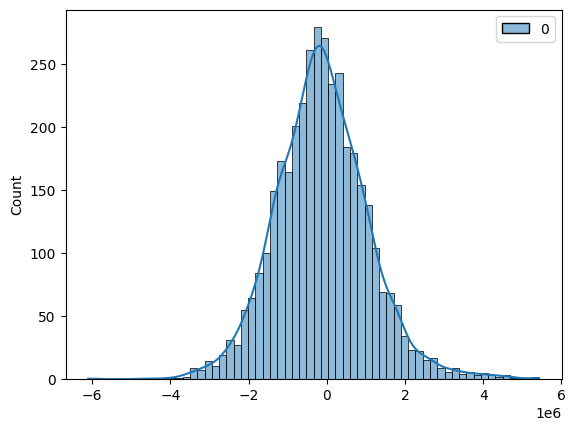

In [ ]:
import seaborn as sns
e = y_test.values.reshape(-1, 1) - y_pred
sns.histplot(e, kde=True)

# Архитектура 2

In [ ]:
model = NN(
    FullConnectedLayer(X.shape[1], 256, LeakyRELU),
    FullConnectedLayer(256, 256, LeakyRELU),
    FullConnectedLayer(256, 1),
)

train(model, X_train.values, y_train.values.reshape(-1, 1), batch_size=512, epochs=200, lr=0.03)

Epoch 1, loss = 23347700937775.046875
Epoch 11, loss = 5265614558503.789062
Epoch 21, loss = 3501757114390.067383
Epoch 31, loss = 2850583703267.330078
Epoch 41, loss = 2511294577000.095703
Epoch 51, loss = 2304159318383.889648
Epoch 61, loss = 2164877389886.583252
Epoch 71, loss = 2064843346506.106201
Epoch 81, loss = 1989524365892.017334
Epoch 91, loss = 1930774379726.027588
Epoch 101, loss = 1883674802036.479248
Epoch 111, loss = 1845080144110.176514
Epoch 121, loss = 1812884370502.557129
Epoch 131, loss = 1785623074688.879395
Epoch 141, loss = 1762244912938.889893
Epoch 151, loss = 1741974789391.906250
Epoch 161, loss = 1724228623950.202148
Epoch 171, loss = 1708559219918.438232
Epoch 181, loss = 1694618993273.633789
Epoch 191, loss = 1682134088361.034668


In [ ]:
y_pred = model.forward(X_test)

print(r2_score(y_pred, y_test))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.40904621978300704
900149.6664732998
1391998908101.4194


# Архитектура 3

In [ ]:
model = NN(
    FullConnectedLayer(X.shape[1], 512, RELU),
    FullConnectedLayer(512, 256, RELU),
    FullConnectedLayer(256, 1),
)

train(model, X_train.values, y_train.values.reshape(-1, 1), batch_size=512, epochs=100, lr=0.3)

Epoch 1, loss = 7768966176691.327148
Epoch 11, loss = 2135730556130.556396
Epoch 21, loss = 1828093730057.807861
Epoch 31, loss = 1721344082965.604736
Epoch 41, loss = 1673604943705.267822
Epoch 51, loss = 1652678569074.919678
Epoch 61, loss = 1637257285995.095703
Epoch 71, loss = 1627148840326.266846
Epoch 81, loss = 1620975067746.958740
Epoch 91, loss = 1619137976936.197754


In [ ]:
y_pred = model.forward(X_test)

print(r2_score(y_pred, y_test))
print(mean_absolute_error(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

-0.4160953262333409
1127082.463312581
2179809272154.2332


# Итог
Моя реализация выдала результат не сильно лучше, чем линейная регрессия, которую я применял в 1 лабораторной, и хуже чем ансамблевые модели. Абсолютной ошибки ниже 900к, пока что получить не удалось.

Изначально изменял веса по 1 записи, но модель плохо обучалась,написал batch и Adam. Немного запарился с реализаций, постоянно путался в размерностях, параллельно на листочке рисовал промежуточные матрицы. Но в целом картинка сложилась)
При использовании LeakyRELU модель заметно дольше обучается